# 01 — Exploratory Data Analysis: CSE-CIC-IDS2018

This notebook explores the [CSE-CIC-IDS2018](https://www.unb.ca/cic/datasets/ids-2018.html) dataset (parquet format), which will be used to train a **Neural ODE Autoencoder** for unsupervised DDoS detection.

**Goals:**
1. **File inventory** — List all parquet files and their sizes.
2. **Schema consistency** — Verify that all files share the same column structure.
3. **Data quality** — Check for duplicates, NaN/Inf values, and data types.
4. **Label distribution** — Understand the class balance between benign traffic and different attack types.
5. **Descriptive statistics** — Summarize key features relevant to the Neural ODE model.
6. **Flow distribution per file** — Understand how flows are distributed across capture days.
7. **Benign vs. Attack comparison** — Compare feature distributions between normal and attack traffic.
8. **Feature correlation** — Identify redundant or highly correlated features.
9. **Missing values audit** — Final data quality check before preprocessing.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

RAW_DIR = os.path.join("..", "data", "raw", "archive")
print(f"Looking for parquet files in: {os.path.abspath(RAW_DIR)}")

Looking for parquet files in: /Users/micolmichanie/Research/neural-ode-autoencoder/data/raw/archive


## 1. File Inventory

The CSE-CIC-IDS2018 dataset is split across multiple parquet files, each corresponding to a different day/type of network capture. Each filename encodes the attack type and date.

In [2]:
parquet_files = sorted([f for f in os.listdir(RAW_DIR) if f.endswith(".parquet")])

print(f"Total parquet files: {len(parquet_files)}\n")
total_size = 0
for f in parquet_files:
    size_mb = os.path.getsize(os.path.join(RAW_DIR, f)) / 1e6
    total_size += size_mb
    print(f"  {f:60s} {size_mb:8.1f} MB")
print(f"\n  {'Total':60s} {total_size:8.1f} MB")

Total parquet files: 10

  Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet       83.5 MB
  Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet     76.4 MB
  DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet       89.5 MB
  DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet     33.4 MB
  DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet       98.6 MB
  DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet         58.0 MB
  Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet     51.0 MB
  Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet     29.3 MB
  Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet      104.0 MB
  Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet        101.4 MB

  Total                                                           725.0 MB


## 2. Schema Consistency Check

Before concatenating all files, we verify that every parquet file shares the same column structure and data types. Unlike CSVs, parquet files preserve type information, so we also check dtypes.

In [3]:
# Read each file and check column consistency
column_lists = {}

for f in parquet_files:
    path = os.path.join(RAW_DIR, f)
    df_sample = pd.read_parquet(path).head(5)
    column_lists[f] = list(df_sample.columns)
    print(f"\n--- {f[:55]} ---")
    print(f"  Columns: {len(df_sample.columns)}")
    print(f"  First 5 columns: {list(df_sample.columns[:5])}")

# Check if all files share the same columns (order matters for parquet)
ref_cols = column_lists[parquet_files[0]]
all_same = all(cols == ref_cols for cols in column_lists.values())
print(f"\n{'✓' if all_same else '✗'} All columns consistent across files: {all_same}")

if not all_same:
    for f, cols in column_lists.items():
        diff = set(cols).symmetric_difference(set(ref_cols))
        if diff:
            print(f"  {f}: differences = {diff}")


--- Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parq ---
  Columns: 78
  First 5 columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total']

--- Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMet ---
  Columns: 78
  First 5 columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total']

--- DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parq ---
  Columns: 78
  First 5 columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total']

--- DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.pa ---
  Columns: 78
  First 5 columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total']

--- DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parq ---
  Columns: 78
  First 5 columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets 

## 3. Full Data Load

We load all parquet files into a single DataFrame. Parquet is a columnar format that preserves data types natively — no string-to-numeric conversion issues like with CSVs.

In [4]:
dfs = []
for f in parquet_files:
    path = os.path.join(RAW_DIR, f)
    df = pd.read_parquet(path)
    df["_source_file"] = f
    dfs.append(df)
    print(f"  {f[:55]:55s} {len(df):>10,} rows")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows: {len(df_all):,}")
print(f"Total columns: {len(df_all.columns)}")

  Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parq    771,587 rows
  Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMet    619,346 rows
  DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parq    954,846 rows
  DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.pa    561,396 rows
  DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parq    794,812 rows
  DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parque    591,873 rows
  Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.p    456,873 rows
  Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.pa    249,170 rows
  Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parq    830,224 rows
  Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parque    829,405 rows

Total rows: 6,659,532
Total columns: 79


## 4. Data Quality Check

The parquet version of CSE-CIC-IDS2018 resolves several issues present in the raw CSVs (no duplicate header rows, no string-encoded Inf, no duplicate `Fwd Header Length` column). However, we still check for:

1. **Duplicate rows** — Fully identical rows that could bias the model.
2. **Inf / NaN values** — Particularly in rate-based columns (`Flow Bytes/s`, `Flow Packets/s`).
3. **Data types** — Confirm all feature columns are numeric.

In [5]:
# 4a. Duplicate rows
n_duplicates = df_all.drop(columns=["_source_file"]).duplicated().sum()
print(f"Fully duplicated rows: {n_duplicates:,} ({n_duplicates / len(df_all) * 100:.2f}%)")
print(f"  → These will be removed during preprocessing to avoid biasing the model.")

Fully duplicated rows: 339,529 (5.10%)
  → These will be removed during preprocessing to avoid biasing the model.


In [6]:
# 4b. Inf and NaN in rate columns
for col in ["Flow Bytes/s", "Flow Packets/s"]:
    if col in df_all.columns:
        n_inf = np.isinf(df_all[col]).sum()
        n_nan = df_all[col].isna().sum()
        print(f"{col}:")
        print(f"  Infinity: {n_inf:,}")
        print(f"  NaN:      {n_nan:,}")

Flow Bytes/s:
  Infinity: 0
  NaN:      0
Flow Packets/s:
  Infinity: 0
  NaN:      0


In [7]:
# 4c. Data types overview — confirm all features are numeric except Label
print("Data types:\n")
dtype_counts = df_all.drop(columns=["_source_file"]).dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):15s} {count:3d} columns")

non_numeric = df_all.drop(columns=["_source_file"]).select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNon-numeric columns: {non_numeric}")

Data types:

  float32          22 columns
  int8             20 columns
  int32            15 columns
  float64          15 columns
  int16             4 columns
  int64             1 columns
  object            1 columns

Non-numeric columns: ['Label']


## 5. Label Distribution

Understanding the class balance is critical for our anomaly detection approach. Since the Neural ODE Autoencoder is trained **only on benign traffic**, we need to know:
- How much benign data is available for training.
- What types of attacks exist and their relative prevalence.
- Which files contain which attack types (the dataset is organized by attack day).

In [8]:
# Overall label distribution
label_counts = df_all["Label"].value_counts()
label_pct = (label_counts / len(df_all) * 100).round(2)

label_summary = pd.DataFrame({"Count": label_counts, "Percentage": label_pct})
print(label_summary.to_string())

print(f"\nTotal benign: {label_counts.get('Benign', 0):,} ({label_pct.get('Benign', 0):.1f}%)")
print(f"Total attacks: {(len(df_all) - label_counts.get('Benign', 0)):,} ({100 - label_pct.get('Benign', 0):.1f}%)")

                            Count  Percentage
Label                                        
Benign                    5329008       80.02
DDoS attacks-LOIC-HTTP     575364        8.64
DDOS attack-HOIC           198861        2.99
DoS attacks-Hulk           145199        2.18
Bot                        144535        2.17
Infilteration              118483        1.78
SSH-Bruteforce              94048        1.41
DoS attacks-GoldenEye       41406        0.62
DoS attacks-Slowloris        9908        0.15
DDOS attack-LOIC-UDP         1730        0.03
Brute Force -Web              568        0.01
Brute Force -XSS              229        0.00
SQL Injection                  85        0.00
DoS attacks-SlowHTTPTest       55        0.00
FTP-BruteForce                 53        0.00

Total benign: 5,329,008 (80.0%)
Total attacks: 1,330,524 (20.0%)


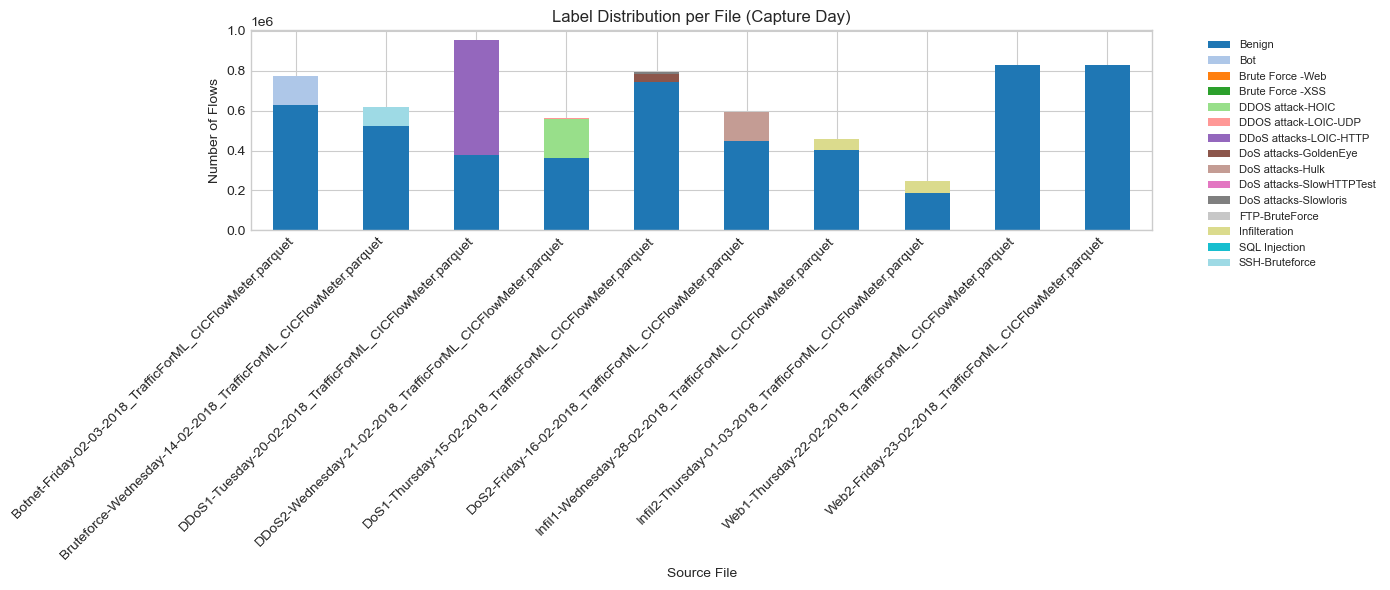

In [9]:
# Label distribution per source file — helps understand which days contain which attacks
fig, ax = plt.subplots(figsize=(14, 6))

pivot = df_all.groupby(["_source_file", "Label"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")

ax.set_title("Label Distribution per File (Capture Day)")
ax.set_xlabel("Source File")
ax.set_ylabel("Number of Flows")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Descriptive Statistics of Key Features

We focus on features that are most relevant for the Neural ODE model, grouped by their role:

- **Temporal dynamics** — Inter-arrival times (IAT), flow rates, active/idle periods. These capture the *rhythm* of traffic, which is what the Neural ODE will learn to model.
- **Traffic structure** — Packet lengths and counts, which characterize the *shape* of each flow.
- **TCP behavior** — SYN/FIN/RST flag counts and initial window sizes, which reveal connection-level patterns that differ between normal and attack traffic.

In [10]:
# Key features for the Neural ODE, organized by category
# Note: parquet column names differ slightly from CSV (e.g., "Init Fwd Win Bytes" not "Init_Win_bytes_forward")
key_features = [
    # Temporal dynamics — these are the most important for the Neural ODE,
    # as it learns continuous-time evolution of traffic patterns
    "Flow IAT Mean", "Flow IAT Std", "Flow IAT Max", "Flow IAT Min",
    "Fwd IAT Mean", "Bwd IAT Mean",
    "Flow Bytes/s", "Flow Packets/s",
    "Active Mean", "Idle Mean",
    # Traffic structure — characterizes flow shape and volume
    "Fwd Packet Length Mean", "Bwd Packet Length Mean",
    "Packet Length Variance",
    "Total Fwd Packets", "Total Backward Packets",
    # TCP behavior — connection-level patterns
    "SYN Flag Count", "FIN Flag Count", "RST Flag Count",
    "Init Fwd Win Bytes", "Init Bwd Win Bytes",
]

# Filter to features that actually exist in the dataset
available_features = [f for f in key_features if f in df_all.columns]
missing_features = [f for f in key_features if f not in df_all.columns]

if missing_features:
    print(f"Features not found in dataset: {missing_features}\n")

print(f"Available key features: {len(available_features)} / {len(key_features)}\n")
df_all[available_features].describe().T.round(2)

Available key features: 20 / 20



,count,mean,std,min,25%,50%,75%,max
Flow IAT Mean,6659532.0,5532005.50,3.475313e+08,-8.282200e+11,1866.00,99444.95,640262.31,1.200000e+08
Flow IAT Std,6659532.0,1852280.75,5.278548e+08,0.000000e+00,0.00,12805.80,473513.83,4.743545e+11
Flow IAT Max,6659532.0,9931651.50,1.029519e+09,-8.282200e+11,7372.00,291315.50,4518458.75,9.797810e+11
Flow IAT Min,6659532.0,3609681.64,1.167175e+09,-9.474050e+11,4.00,30.00,1089.00,1.200000e+08
Fwd IAT Mean,6659532.0,5889005.00,3.475389e+08,-8.282200e+11,238.00,39568.00,1063350.81,1.200000e+08
Bwd IAT Mean,6659532.0,838262.44,3.940740e+06,0.000000e+00,0.00,2838.67,294126.78,1.200000e+08
Flow Bytes/s,6659532.0,131383.84,2.458488e+06,0.000000e+00,50.12,887.75,44001.07,1.806643e+09
Flow Packets/s,6659532.0,5704.36,7.454582e+04,-1.000000e-02,1.80,11.70,702.25,4.000000e+06
Active Mean,6659532.0,117121.62,1.652950e+06,0.000000e+00,0.00,0.00,0.00,1.140000e+08
Idle Mean,6659532.0,7218759.50,4.104132e+08,0.000000e+00,0.00,0.00,0.00,3.955714e+11


## 7. Flow Distribution per Capture Day

Since the parquet files lack timestamps, we analyze the flow distribution per file (each file corresponds to a specific capture day and attack type). This helps us understand how the sequential split (70/15/15) will divide the data.

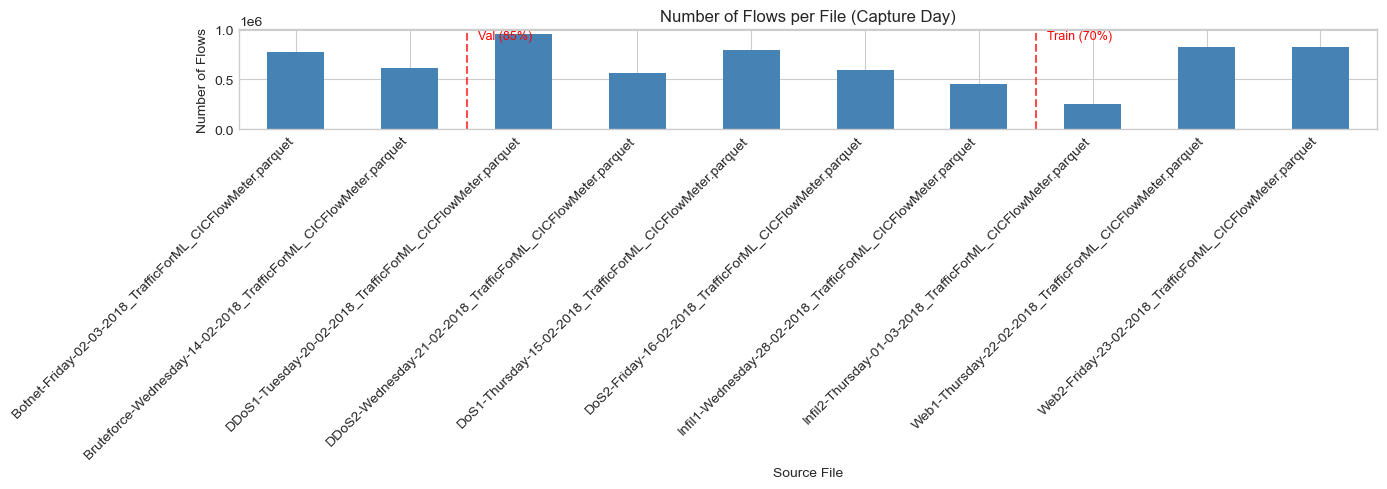


Total flows: 6,659,532
  Train (70%): ~4,661,672 flows
  Val   (15%): ~998,929 flows
  Test  (15%): ~998,929 flows


In [11]:
# Flows per file with attack breakdown
flows_per_file = df_all.groupby("_source_file").size().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
flows_per_file.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of Flows per File (Capture Day)")
ax.set_ylabel("Number of Flows")
ax.set_xlabel("Source File")
plt.xticks(rotation=45, ha="right")

# Mark the sequential split boundaries (70/15/15)
total = len(df_all)
cumsum = 0
split_labels = {"Train (70%)": 0.70, "Val (85%)": 0.85}
for label, threshold in split_labels.items():
    target = total * threshold
    for i, (f, count) in enumerate(flows_per_file.items()):
        cumsum += count
        if cumsum >= target:
            ax.axvline(x=i + 0.5, color="red", linestyle="--", alpha=0.7)
            ax.text(i + 0.6, ax.get_ylim()[1] * 0.9, label, fontsize=9, color="red")
            break

plt.tight_layout()
plt.show()

print(f"\nTotal flows: {total:,}")
print(f"  Train (70%): ~{int(total * 0.70):,} flows")
print(f"  Val   (15%): ~{int(total * 0.15):,} flows")
print(f"  Test  (15%): ~{int(total * 0.15):,} flows")

## 8. Feature Distributions: Benign vs. Attack Traffic

This is the most important visualization for our project. The Neural ODE Autoencoder works by learning the *normal* distribution of traffic features — if benign and attack traffic have clearly different distributions, the model should be able to detect anomalies via high reconstruction error.

We compare histograms of key features between benign and attack flows. Features with **greater distributional separation** will contribute more to the model's discriminative power.

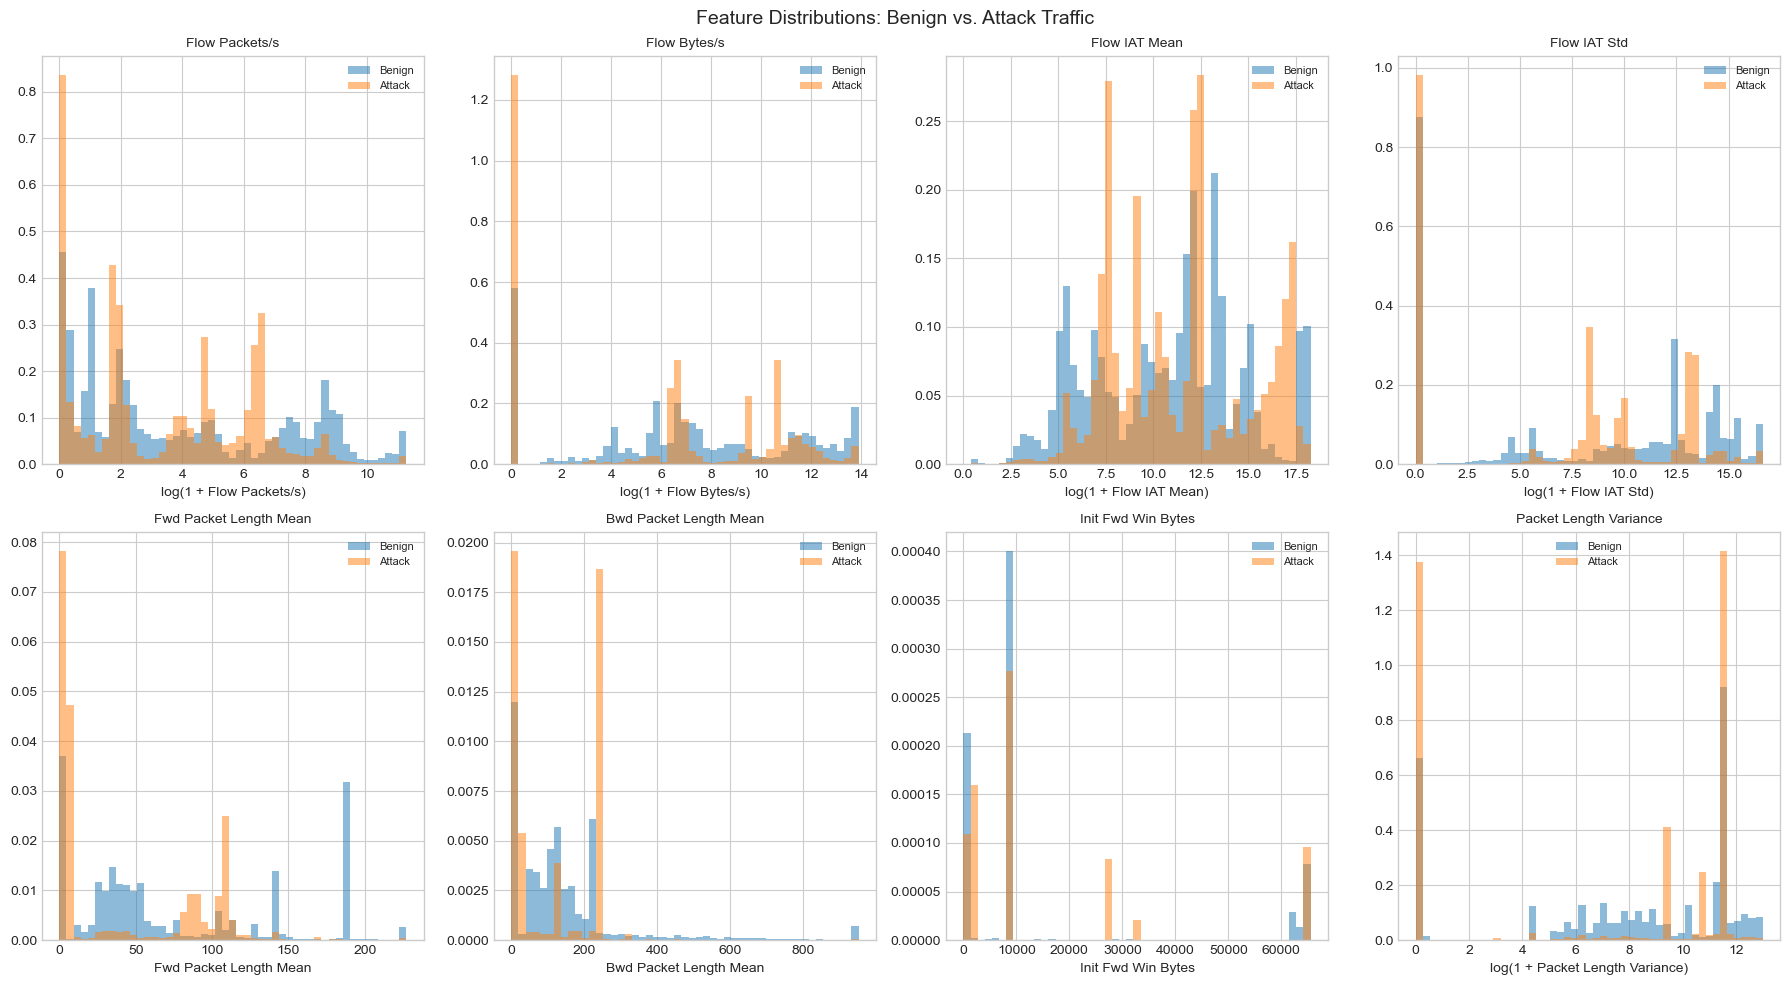

In [12]:
# Create binary label column: benign (0) vs. attack (1)
df_all["is_attack"] = (df_all["Label"] != "Benign").astype(int)

# Features to compare — selected for their expected discriminative power
compare_features = [
    "Flow Packets/s", "Flow Bytes/s",
    "Flow IAT Mean", "Flow IAT Std",
    "Fwd Packet Length Mean", "Bwd Packet Length Mean",
    "Init Fwd Win Bytes", "Packet Length Variance",
]
compare_features = [f for f in compare_features if f in df_all.columns]

n_feats = len(compare_features)
fig, axes = plt.subplots(2, (n_feats + 1) // 2, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(compare_features):
    ax = axes[i]
    benign_vals = df_all.loc[df_all["is_attack"] == 0, feat].dropna()
    attack_vals = df_all.loc[df_all["is_attack"] == 1, feat].dropna()

    # Use log scale if values span a very wide range
    use_log = benign_vals.max() > 1000 * (benign_vals.median() + 1)

    if use_log:
        benign_plot = np.log1p(benign_vals)
        attack_plot = np.log1p(attack_vals)
        ax.set_xlabel(f"log(1 + {feat})")
    else:
        benign_plot = benign_vals
        attack_plot = attack_vals
        ax.set_xlabel(feat)

    # Clip extreme outliers for cleaner visualization
    p99 = np.percentile(pd.concat([benign_plot, attack_plot]).dropna(), 99)
    bins = np.linspace(0, p99, 50)

    ax.hist(benign_plot.clip(upper=p99), bins=bins, alpha=0.5, label="Benign", density=True)
    ax.hist(attack_plot.clip(upper=p99), bins=bins, alpha=0.5, label="Attack", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions: Benign vs. Attack Traffic", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Feature Correlation Matrix

Highly correlated features carry redundant information and can slow training without improving model performance. This correlation matrix helps identify groups of correlated features that could potentially be reduced through feature selection or PCA in future iterations.

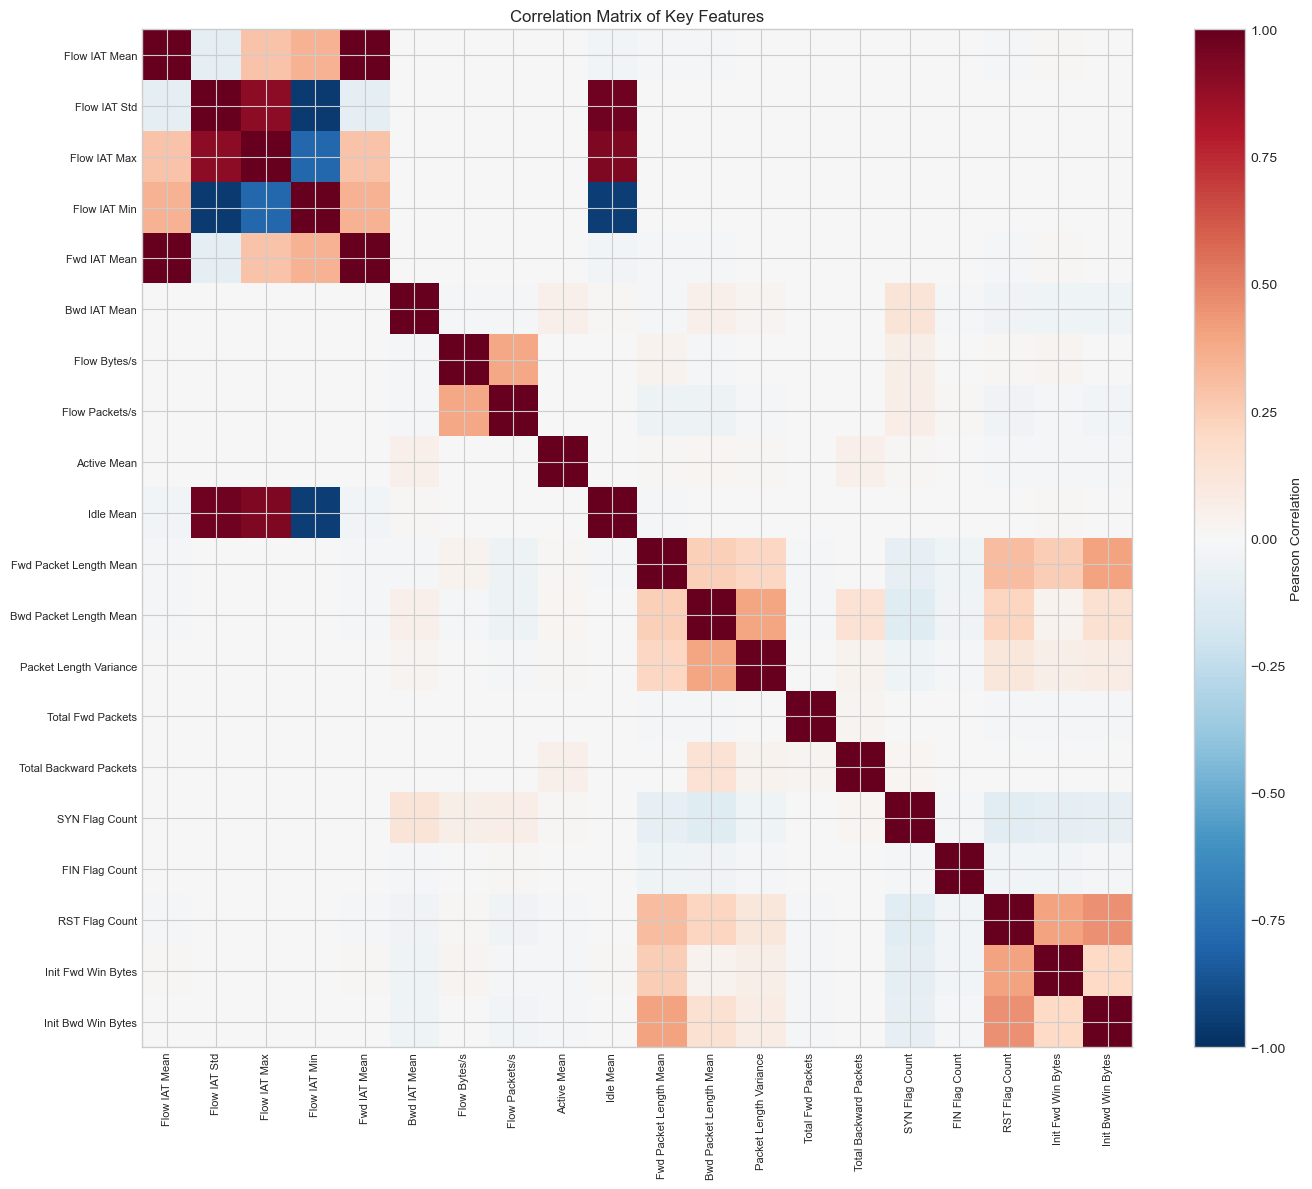

In [13]:
# Correlation matrix of key features
corr_features = [f for f in available_features if f in df_all.columns]
corr_matrix = df_all[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=90, fontsize=8)
ax.set_yticklabels(corr_features, fontsize=8)
plt.colorbar(im, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation Matrix of Key Features")
plt.tight_layout()
plt.show()

## 10. Missing Values Audit

A final check on data quality before preprocessing. Columns with a high percentage of missing values may need special treatment (imputation strategy, or removal if too sparse). The preprocessing pipeline uses **median imputation** for NaN values.

In [14]:
# NaN counts per column (only showing columns that have missing values)
nan_counts = df_all.isna().sum()
nan_nonzero = nan_counts[nan_counts > 0].sort_values(ascending=False)

if len(nan_nonzero) > 0:
    print("Columns with missing values:\n")
    for col, count in nan_nonzero.items():
        pct = count / len(df_all) * 100
        print(f"  {col:40s} {count:>10,} ({pct:.2f}%)")
else:
    print("No missing values found in the dataset.")

print(f"\nTotal columns: {len(df_all.columns)}")
print(f"Numeric columns: {len(df_all.select_dtypes(include=[np.number]).columns)}")

No missing values found in the dataset.

Total columns: 80
Numeric columns: 78
